<a href="https://colab.research.google.com/github/vanecornejo/EDP-II/blob/main/Inventario%20con%20limitaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Inventario de varios artículos con limitación de almacén**

**Ejemplo 11.2-3**

Los datos siguientes describen tres artículos de inventario:

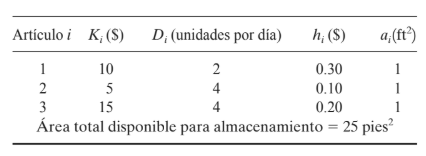

## Datos del Ejemplo 11.2-3

Se consideran tres artículos con los siguientes parámetros:

- $D_i$: demanda diaria (unidades por día)
- $K_i$: costo de ordenar (\$)
- $h_i$: costo de mantenimiento (\$ por unidad-día)
- $a_i$: área requerida por unidad (ft²)

Área total disponible:
$$ A = 25 \text{ ft}^2 $$


Vamos a implementar el modelo EOQ multiartículo con limitación de espacio utilizando el método de tres pasos.


In [60]:
# Importamos librería necesaria

import numpy as np
import sympy as sp
import scipy.optimize as opt

In [61]:
# Demanda diaria
D = np.array([10, 25, 15])

# Costos de ordenar
K = np.array([2, 4, 4])

# Costos de mantenimiento
h = np.array([0.30, 0.10, 0.20])

# Área por unidad (ft^2)
a = np.array([1, 1, 1])

# Área total disponible
A = 25

## **Paso 1:** EOQ sin restricción

El EOQ clásico para cada artículo es:

$$ Q_i^* = \sqrt{\frac{2K_iD_i}{h_i}} $$


In [62]:
Q_eoq = np.sqrt(2*K*D/h)
Q_eoq

array([11.54700538, 44.72135955, 24.49489743])

Verificamos si las cantidades EOQ cumplen la restricción de almacenamiento:

In [63]:
np.dot(a, Q_eoq)

np.float64(80.7632623616201)

## **Paso 2:** Formulación del Lagrangiano

La función objetivo es:

$$ Z = \sum_{i=1}^n \left(\frac{K_iD_i}{Q_i} + \frac{h_iQ_i}{2}\right) $$

Con la restricción:

$$ \sum_{i=1}^n a_i Q_i \le A $$

El Lagrangiano es:

$$ L = \sum_i \left(\frac{K_iD_i}{Q_i} + \frac{h_iQ_i}{2}\right)
+ \lambda\left(\sum_i a_i Q_i - A\right) $$

Derivando respecto a $Q_i$:

$$ -\frac{K_iD_i}{Q_i^2} + \frac{h_i}{2} + \lambda a_i = 0 $$

Despejando:

$$ Q_i(\lambda) =
\sqrt{\frac{K_iD_i}{\frac{h_i}{2} + \lambda a_i}} $$


In [64]:
# Uso de sympy
lam = sp.symbols('lam')

Qi = [sp.sqrt(K[i]*D[i]/(h[i]/2 + lam*a[i])) for i in range(3)]
Qi

[2*sqrt(5)*sqrt(1/(lam + 0.15)),
 10*sqrt(1/(lam + 0.05)),
 2*sqrt(15)*sqrt(1/(lam + 0.1))]

## **Paso 3:** Cálculo del multiplicador de Lagrange

Se obtiene $λ$ resolviendo:

$$ \sum_{i=1}^n a_i Q_i(\lambda) = A $$


In [65]:
expr = sum(a[i]*Qi[i] for i in range(3)) - A

# Usamos sympy
lam_sol = sp.nsolve(expr, -0.035, tol=1e-14, maxsteps=50)
lam_sol

0.703644080132878

Sustituyendo $λ$ en las expresiones de $Q_i$:

In [66]:
Q_opt = [Qi[i].subs(lam, lam_sol).evalf() for i in range(3)]
Q_opt

[4.84034794112509, 11.5190550539517, 8.64059700492320]

Verificamos que la restricción se cumple:

In [67]:
sum(Q_opt)

25.0000000000000

### Validación numérica con SciPy

Se resuelve el mismo problema usando optimización no lineal restringida.


In [68]:
def cost(Q):
    return np.sum(K*D/Q + h*Q/2)

In [69]:
cons = ({'type': 'ineq',
         'fun': lambda Q: A - np.dot(a, Q)})

In [70]:
bnds = [(1e-6, None)]*3
Q0 = Q_eoq

In [71]:
# Uso de spicy
res = opt.minimize(cost, Q0, bounds=bnds, constraints=cons)
res.x

array([ 4.84007866, 11.51818689,  8.64173446])

In [72]:
print("Así, los resultados óptimos del modelo EOQ con restricción de almacén:\n")

print("Q1 = {:.2f} unidades".format(Q_opt[0]))
print("Q2 = {:.2f} unidades".format(Q_opt[1]))
print("Q3 = {:.2f} unidades".format(Q_opt[2]))

Así, los resultados óptimos del modelo EOQ con restricción de almacén:

Q1 = 4.84 unidades
Q2 = 11.52 unidades
Q3 = 8.64 unidades


In [73]:
print("\nVerificación de la restricción de almacenamiento:")
print("Q1 + Q2 + Q3 = {:.2f} ft^2".format(sum(Q_opt)))
print("Área disponible = {} ft^2".format(A))


Verificación de la restricción de almacenamiento:
Q1 + Q2 + Q3 = 25.00 ft^2
Área disponible = 25 ft^2


In [74]:
print("\nMultiplicador de Lagrange:")
print("λ = {:.5f}".format(float(lam_sol)))


Multiplicador de Lagrange:
λ = 0.70364
